<a href="https://colab.research.google.com/github/anamitra-tech/ML-Projects/blob/main/churned_customers_predictions_XGBOOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.8965
[[1778   18]
 [ 189   15]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1796
           1       0.45      0.07      0.13       204

    accuracy                           0.90      2000
   macro avg       0.68      0.53      0.54      2000
weighted avg       0.86      0.90      0.86      2000

                     feature  importance
24           low_tenure_flag    0.364770
16                csat score    0.087820
23            low_login_flag    0.068955
1              tenure months    0.038862
3             monthly logins    0.030029
27          low_revenue_flag    0.022496
8        last login days ago    0.020673
11          discount applied    0.019195
0           customer segment    0.018757
5           avg session time    0.018563
26      low_monthly_fee_flag    0.018441
14       avg resolution time    0.018249
20                 nps score    0.017796
10             total revenue    0.017736
9             

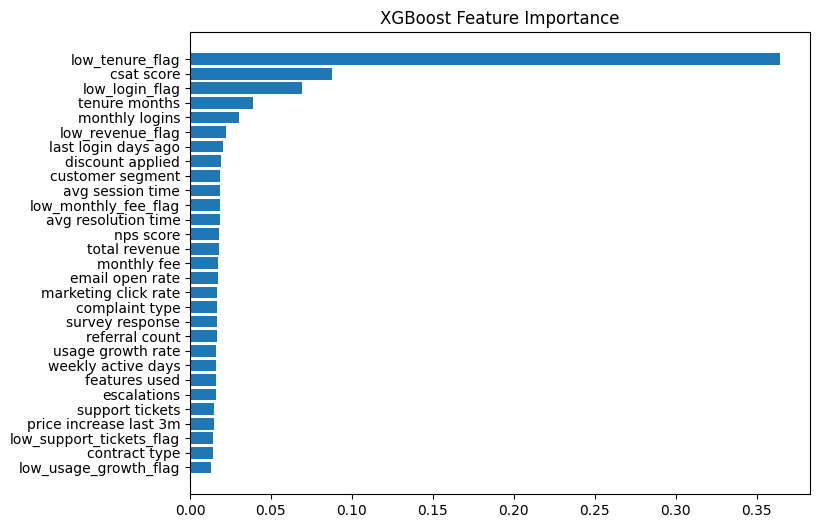

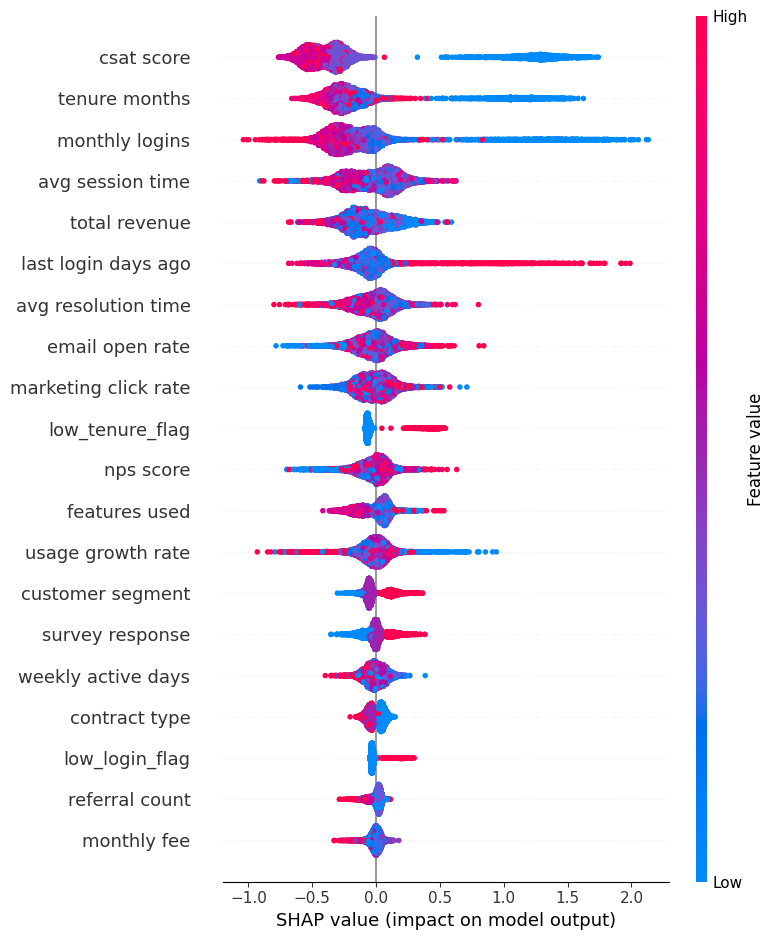

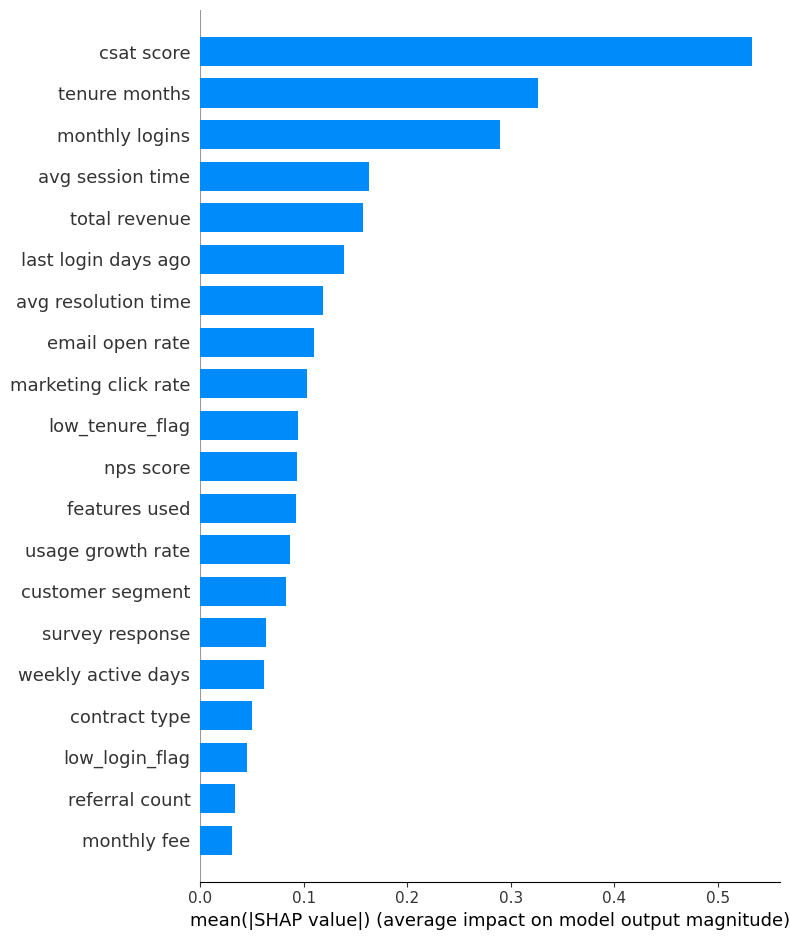

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import shap

# Load data
data = pd.read_csv('/content/customer_churn_buisness_dataset.csv')

# Drop unwanted columns
df = data.drop(columns=['country','city','payment_failures','customer_id','payment_method','gender','age','signup_channel'])

# Clean column names
df.columns = df.columns.str.replace('_', ' ', regex=False)

# Feature engineering called flag style the int converts to 0/1

df['low_login_flag'] = (df['monthly logins'] < 7).astype(int)
df['low_tenure_flag'] = (df['tenure months'] < 6).astype(int)
df['low_usage_growth_flag'] = (df['usage growth rate'] < 0.17).astype(int)
df['low_monthly_fee_flag'] = (df['monthly fee'] < 50).astype(int)
df['low_revenue_flag'] = (df['total revenue'] < 720).astype(int)
df['low_support_tickets_flag'] = (df['support tickets'] < 3).astype(int)

df['discount applied']= df['discount applied'].map({'Yes': 1, 'No': 0})
df['price increase last 3m']=df['price increase last 3m'].map({'Yes': 1, 'No': 0})
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['customer segment', 'contract type', 'complaint type', 'nps score', 'survey response']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # convert to string just in case


# Split target and features
y = df['churn']
X = df.drop(columns=['churn'])

x_train,x_test,y_train,y_test=  train_test_split(
    X,
    y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility
    stratify=y          # very important for churn

)


model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

model.fit(x_train,y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.show()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_train)
shap.summary_plot(shap_values, x_train)
shap.summary_plot(shap_values, x_train, plot_type="bar")
